# Networks of persons in relation to organisations


Cf. [this notebook](https://github.com/Sciences-historiques-numeriques/histoire_numerique_methodes/blob/main/analyse_reseaux/reseaux_florence.ipynb) about families and power in Renaissance Florence for an introduction to network analysis with the *networkx* Python library



In [1]:
import pandas as pd


import networkx as nx
from networkx.algorithms import bipartite

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MaxNLocator

from scipy.stats import spearmanr
import statsmodels.api as sm

import numpy as np
import seaborn as sns
import math
import os

In [2]:
### this library allows to do SQL queries on dataframes
import duckdb

In [3]:
### Librairies déjà installées avec Python
import pprint
import csv

import sqlite3 as sql
import pickle

import time
import datetime
from dateutil import parser


from shutil import copyfile


In [4]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [5]:

import network_analysis_functions as naf
import bivariate_library as bl

In [6]:
print(reload(bl))  

<module 'bivariate_library' from '/home/my_venvs/LOD_NicoSidler/notebooks_jupyter/wikidata_exploration/../bivariate_library.py'>


In [7]:
import warnings
warnings.filterwarnings('ignore')


## Get and inspect the data


We use in this notebook the network data prepared in these two files:
* Get the [relationships with SPARQL](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da6-person-organisation-network.md)
* Prepare the [SQL view and export the data to CSV](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da6-person-organisation-network.sql)


Regarding persons, we reuse the file with the persons, their periods of activity and coded countries, that we created in the correspondence analysis chapter.




### Get the network data

In [8]:
### Import information about relations to organisations - df_po

csv_address='da_data/da6-persons-organisations-relations.csv'
df_po = pd.read_csv(csv_address)
df_po.head(3)

,person_uri,organisation_uri,organisation_label,relationship
0,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q23785357,Burschenschaft Germania Erlangen,membership
1,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,employment
2,http://www.wikidata.org/entity/Q1000348,http://www.wikidata.org/entity/Q696757,University of Duisburg-Essen,employment


In [9]:
### Inspect the dataframe and 
# notably if there are missing values
df_po.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29791 entries, 0 to 29790
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   person_uri          29791 non-null  object
 1   organisation_uri    29791 non-null  object
 2   organisation_label  29791 non-null  object
 3   relationship        29791 non-null  object
dtypes: object(4)
memory usage: 931.1+ KB


In [10]:
### Number of types of relationships
df_rela_type=pd.DataFrame(df_po.groupby(by='relationship').size())
df_rela_type.columns=['number']
df_rela_type

,number
relationship,
education,13145
employment,13768
membership,2878


### Get the data about persons

#### First: get the individuals (20000) used for correspondence analysis 


In [11]:
### Information about persons with gender, birth date,
# coded country, etc.
csv_address='da_data/da4-AFC.csv'
### csv_address='da_data/da2-birth-place.csv'
df_p_AFC = pd.read_csv(csv_address)
df_p_AFC.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,23,Northern America,US,United States,United States,USA,United States Can.,1851,1846-1870
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,POINT (3.106389 50.280278),http://www.wikidata.org/entity/Q61573,22,Western Europe,FR,France,France,FRA,France,1846,1846-1870
2,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1806,male,La Rivière-Saint-Sauveur,POINT (0.271389 49.407222),http://www.wikidata.org/entity/Q383959,22,Western Europe,FR,France,France,FRA,France,1851,1846-1870


In [12]:
df_p_AFC=df_p_AFC[['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'REGION', 'NAME_ENGL', 'coded_country', 'periodsActivity']]

In [13]:
### Rename columns to have shorter labels
df_p_AFC.columns=['person_uri',
 'labelPer',
 'birthYear',
 'gender',
 'labelPlace',
 'REGION',
 'NAME_ENGL',
 'country',
 'per_activ'
 ]

In [14]:
### Inspect the dataframe and 
# notably if there are missing values
df_p_AFC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7917 entries, 0 to 7916
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   person_uri  7917 non-null   object
 1   labelPer    7917 non-null   object
 2   birthYear   7917 non-null   int64 
 3   gender      7917 non-null   object
 4   labelPlace  7917 non-null   object
 5   REGION      7917 non-null   object
 6   NAME_ENGL   7917 non-null   object
 7   country     7917 non-null   object
 8   per_activ   7518 non-null   object
dtypes: int64(1), object(8)
memory usage: 556.8+ KB


#### Second: get the individuals (8000) used for clustering


In [15]:
file_address='da_data/da5-MCA-clusters.csv'
df_p_MCA = pd.read_csv(file_address)
df_p_MCA.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_sec1,coded_employer
0,http://www.wikidata.org/entity/Q2993155,Konstantin Kavelin,1818,male,Saint Petersburg,POINT (30.316667 59.95),European Russia,Russian Federation,Russian Federation,1846-1870,11704,historian,publisher
1,http://www.wikidata.org/entity/Q555693,Timofey Granovsky,1813,male,Oryol,POINT (36.069444 52.968611),European Russia,Russian Federation,Russian Federation,1846-1870,14217,university-teacher,university
2,http://www.wikidata.org/entity/Q144535,Herbert Spencer,1820,male,Derby,POINT (-1.476667 52.921667),Northern Europe,United Kingdom,United Kingdom,1846-1870,8360,writer,other


In [16]:
### Rename columns to have shorter labels
df_p_MCA.columns=['person_uri',
 'labelPer',
 'birthYear',
 'gender',
 'labelPlace',
 'geometry',
 'REGION',
 'NAME_ENGL',
 'country',
 'per_activ',
 'pk_person_features',
 'occup_s',
 'empl']

In [17]:
df_p_MCA=df_p_MCA[['person_uri',
 'occup_s',
 'empl']
]

In [18]:
### Inspect the dataframe and 
# notably if there are missing values
df_p_MCA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3300 entries, 0 to 3299
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   person_uri  3300 non-null   object
 1   occup_s     3300 non-null   object
 2   empl        3300 non-null   object
dtypes: object(3)
memory usage: 77.5+ KB


#### Third: add the additional NCA features to the first dataframe

In [19]:
df_p=df_p_AFC.merge(df_p_MCA, left_on=['person_uri'], right_on=['person_uri'], how='left')
df_p=df_p.fillna('')

In [20]:
print(len(df_p))
df_p.iloc[:3]

7917


,person_uri,labelPer,birthYear,gender,labelPlace,REGION,NAME_ENGL,country,per_activ,occup_s,empl
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,Northern America,United States,United States Can.,1846-1870,,
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,Western Europe,France,France,1846-1870,,
2,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1806,male,La Rivière-Saint-Sauveur,Western Europe,France,France,1846-1870,,


We can observe the limits a restriction to persons that only have the additional features: 

if we restrict to persons with MCA features, Albert Einstein would not be taken into account in the analysis of the network!

We cannot proceed with adding insights from clustering to the network: additional information should be first added to our information system.

We could just add the main occupation, with additional preparation (not yet implemented).


In [21]:
### Find Albert Einstein
duckdb.query("""
select *
from df_p
where labelPer like '%Bourd%'
""").to_df()

,person_uri,labelPer,birthYear,gender,labelPlace,REGION,NAME_ENGL,country,per_activ,occup_s,empl
0,http://www.wikidata.org/entity/Q16775651,Louis Bourdeau,1824,male,Rochechouart,Western Europe,France,France,1846-1870,,
1,http://www.wikidata.org/entity/Q2956366,Jean Bourdeau,1848,male,Limoges,Western Europe,France,France,1871-1895,,
2,http://www.wikidata.org/entity/Q18610878,Yvon Bourdet,1920,male,Albussac,Western Europe,France,France,1946-1970,,
3,http://www.wikidata.org/entity/Q156268,Pierre Bourdieu,1930,male,Denguin,Western Europe,France,France,1971-1995,philosopher,education
4,http://www.wikidata.org/entity/Q55626397,Alain Bourdin,1945,male,Orléans,Western Europe,France,France,1971-1995,,


## Inspect the features of the relationships

### Distribution of relationships per country

#### Writing SQL queries with the duckdb library

In [22]:
### Distribution of coded countries
# using the duckdb library and a SQL query

# the result is the same as in the cell below
dfc=duckdb.query("""
    SELECT country, COUNT(*) as num
    FROM df_p
    GROUP BY country
    ORDER BY num DESC
  """).to_df()
dfc

,country,num
0,Germany,1604
1,United States Can.,994
2,France,579
3,Italy,559
4,Poland,511
5,Austria Hungary,489
6,Czechia,484
7,Central Europe,466
8,South America,412
9,Spain Port.,393


In [23]:
### Distribution of coded countries
dfc=pd.DataFrame(df_p.groupby(by=['country']).size())
dfc.sort_values(by=0,ascending=False)


,0
country,
Germany,1604
United States Can.,994
France,579
Italy,559
Poland,511
Austria Hungary,489
Czechia,484
Central Europe,466
South America,412


## Merge the two dataframes

This will restrict the information about relations to the persons that are present in the file with the individuals (*da4-AFC.csv* with additional information from *da5-MCA-clusters.csv*)

In [24]:
df_p=df_p[['person_uri', 'labelPer', 'gender', 'birthYear','country', 'per_activ']]
df_p.head(3)

,person_uri,labelPer,gender,birthYear,country,per_activ
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,male,1806,United States Can.,1846-1870
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,male,1801,France,1846-1870
2,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,male,1806,France,1846-1870


In [25]:
### Merge the two dataframes:
# only relations that involve persons in df_p
# will remain
df_rel=df_po.merge(df_p,on='person_uri')
print(len(df_rel))
df_rel.head(2)

15924


,person_uri,organisation_uri,organisation_label,relationship,labelPer,gender,birthYear,country,per_activ
0,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q23785357,Burschenschaft Germania Erlangen,membership,Horst Baier,male,1933,Czechia,1971-1995
1,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,employment,Horst Baier,male,1933,Czechia,1971-1995


### Inspect the merge result

In [26]:
### Unique persons
unique_p=pd.DataFrame(df_rel['person_uri'].unique())
unique_p.columns=['person_uri']
len_up=len(unique_p)
print(f"Number of persons with relations: {len_up}")
unique_p.head(2)

Number of persons with relations: 5485


,person_uri
0,http://www.wikidata.org/entity/Q1000087
1,http://www.wikidata.org/entity/Q1000348


In [27]:
### Number of types of relationships and per person proportion
df_rela_type=pd.DataFrame(df_rel.groupby(by='relationship').size())
df_rela_type.columns=['number']
df_rela_type['propr_rela_per_person']=df_rela_type['number'].apply(lambda x : x/len_up)
df_rela_type

,number,propr_rela_per_person
relationship,,
education,6630,1.208751
employment,7251,1.321969
membership,2043,0.372470


### Restriction to persons with memberships

We observe from the former queries, that some persons have no memberships. 

In our analysis of the field, notably with a question about correlation  we decide 


In [28]:
###  Count number of relations per person
df_rel = duckdb.query("""
    with tw1 AS (
    -- we create a list of persons with memberships
    SELECT DISTINCT person_uri
    FROM df_rel
    WHERE relationship='membership'
    )
    SELECT *
    FROM df_rel 
    WHERE person_uri IN (SELECT person_uri FROM tw1)
    
""").to_df()
print(len(df_rel))
df_rel.iloc[:2]

5739


,person_uri,organisation_uri,organisation_label,relationship,labelPer,gender,birthYear,country,per_activ
0,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q23785357,Burschenschaft Germania Erlangen,membership,Horst Baier,male,1933,Czechia,1971-1995
1,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,employment,Horst Baier,male,1933,Czechia,1971-1995


In [29]:
###  Count number of relations per person
duckdb.query("""
    WITH tw1 AS (
    -- we create a list of unique persons
    SELECT DISTINCT person_uri
    FROM df_rel
    )
    SELECT relationship, COUNT(*) as number, 
            ROUND(COUNT(*)/(SELECT COUNT(*) FROM tw1),2) AS propr_rela_per_person
    FROM df_rel 
    GROUP BY relationship
    ORDER BY relationship    
""").to_df()

,relationship,number,propr_rela_per_person
0,education,1685,1.39
1,employment,2011,1.66
2,membership,2043,1.69


### Number of relationships per person

In [30]:
###  Count number of relations per person
print('Number of relations per person:')
df_pn = duckdb.query("""
    with tw1 AS (
    SELECT person_uri, COUNT(*) as number
    FROM df_rel
    GROUP BY person_uri
    )
    SELECT labelPer,number, birthYear,country,per_activ, tw1.person_uri
    from tw1 join df_p on df_p.person_uri = tw1.person_uri
    ORDER BY number DESC
""").to_df()
df_pn.iloc[:8]

Number of relations per person:


,labelPer,number,birthYear,country,per_activ,person_uri
0,Raymond Aron,20,1905,France,1946-1970,http://www.wikidata.org/entity/Q160640
1,Manuel Castells,18,1942,Spain Port.,1971-1995,http://www.wikidata.org/entity/Q310161
2,Mary Douglas,17,1921,Italy,1946-1970,http://www.wikidata.org/entity/Q231349
3,W. E. B. Du Bois,16,1868,United States Can.,1896-1920,http://www.wikidata.org/entity/Q158060
4,Jutta Allmendinger,15,1956,Germany,1996-2020,http://www.wikidata.org/entity/Q1714580
5,Ralf Dahrendorf,15,1929,Germany,1971-1995,http://www.wikidata.org/entity/Q76959
6,Maurizio Alì,15,1979,Italy,,http://www.wikidata.org/entity/Q43632352
7,Jürgen Habermas,15,1929,Germany,1971-1995,http://www.wikidata.org/entity/Q76357


In [31]:
### Statistical profile
print(df_pn.number.describe())

count    1208.000000
mean        4.750828
std         2.855829
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        20.000000
Name: number, dtype: float64


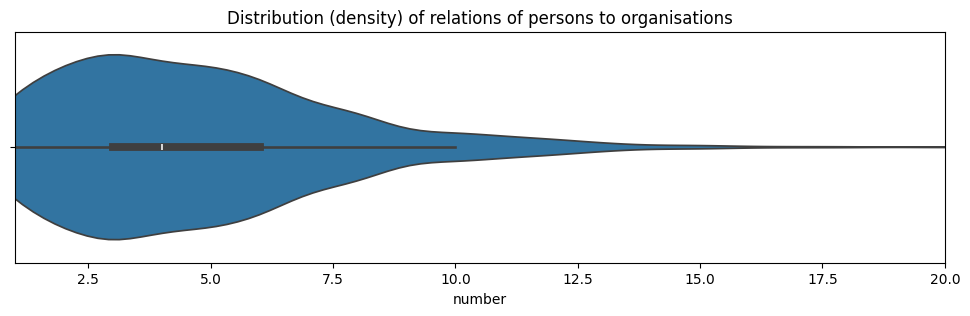

In [32]:
# Plot the distribution number of relations to organisations

min_val = df_pn.number.min()
max_val = df_pn.number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df_pn.number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

### Inspect the persons with a high number of relationships

In [33]:
### Persons that have 10 or more relations to organisations
print(len(df_pn[df_pn.number > 9]))

86


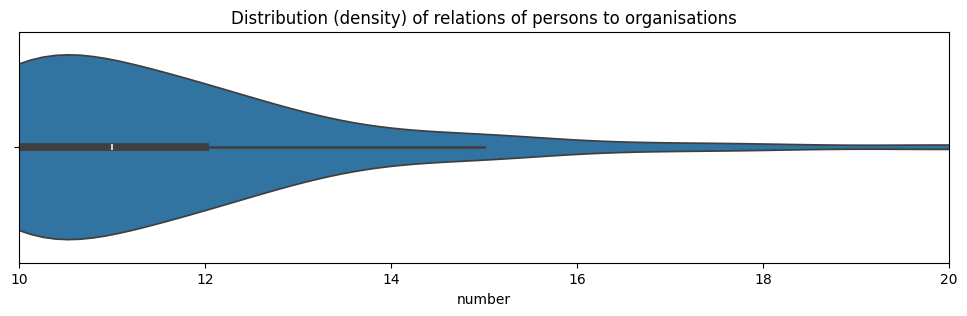

In [34]:
# Plot the distribution number of relations to organisations

df=df_pn[df_pn.number > 9]

min_val = df.number.min()
max_val = df.number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

In [35]:
### Number of types of relationships, all the persons
df_rela_type=pd.DataFrame(df_rel.groupby(by='relationship').size())
df_rela_type.columns=['number']

### Type of relationship of the 700 more connected persons (merge on the fly)
df_pn[df_pn.number > 9].merge(df_rel, left_on='person_uri', right_on='person_uri').groupby(by='relationship').size()

df_rela_type=df_rela_type.join((df_pn[df_pn.number > 9].\
                   merge(df_rel, left_on='person_uri', right_on='person_uri').groupby(by='relationship').size()).rename('rel_700'))

### Add the proportion between all the relations and those of the most connected persons
df_rela_type['prop']=df_rela_type.apply(lambda x: x['rel_700']/x['number'], axis=1)
### We observe that memberships are overrepresented for this very well known persons
df_rela_type


,number,rel_700,prop
relationship,,,
education,1685,247,0.146588
employment,2011,415,0.206365
membership,2043,338,0.165443


## Relationships with organisations in relation to activity periods

Observe if periods are specific to relations and which ones 

In [36]:
### Distribution of RELATIONS by periods of activity
activities_per = pd.DataFrame(df_rel.groupby(by='per_activ').size())
activities_per.columns=['number_rel']
print(activities_per)

           number_rel
per_activ            
                  159
1846-1870          66
1871-1895         171
1896-1920         397
1921-1945         560
1946-1970        1088
1971-1995        2169
1996-2020        1129


In [37]:
### Distribution of PERSONS by periods of activity
period_per = pd.DataFrame(df_p.groupby(by='per_activ').size())
period_per.columns=['number_per']
print(period_per)

           number_per
per_activ            
                  399
1846-1870          36
1871-1895         100
1896-1920         278
1921-1945         460
1946-1970        1005
1971-1995        3202
1996-2020        2437


In [38]:
df_ap_per=activities_per.join(period_per)

### Number of activities divided by number of persons
df_ap_per['proportion']=df_ap_per.apply(lambda x: x.number_rel/x.number_per, axis=1).round(3)
df_ap_per

,number_rel,number_per,proportion
per_activ,,,
,159,399,0.398
1846-1870,66,36,1.833
1871-1895,171,100,1.710
1896-1920,397,278,1.428
1921-1945,560,460,1.217
1946-1970,1088,1005,1.083
1971-1995,2169,3202,0.677
1996-2020,1129,2437,0.463


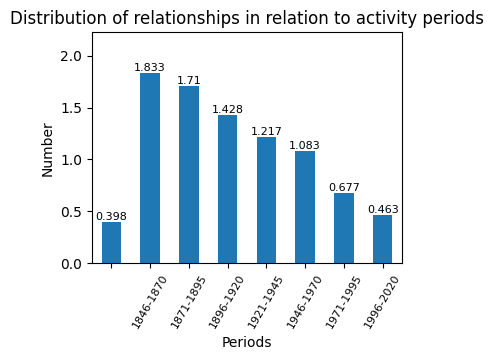

In [39]:
### Plot the evolution in time


ax = df_ap_per.proportion.plot(kind='bar',rot=50, fontsize=10, figsize=(4,3))
ax.bar_label(ax.containers[-1], size=8)


current_min, current_max = ax.get_ylim()
ax.set_ylim(current_min, current_max+0.3)

# Rotate labels 60 degrees and reduce font size
plt.xticks(rotation=60, fontsize=8)

plt.ylabel('Number')
plt.xlabel('Periods')
plt.title('Distribution of relationships in relation to activity periods')
plt.show()

In [40]:
### Create a cross-table
crosstab = pd.crosstab(df_rel['per_activ'],df_rel['relationship'])
# Optional: Remove the index name if you want a cleaner look
# crosstab.index.name = None
crosstab.columns.name = None
crosstab


,education,employment,membership
per_activ,,,
,53,49,57
1846-1870,22,8,36
1871-1895,44,50,77
1896-1920,128,116,153
1921-1945,172,198,190
1946-1970,320,380,388
1971-1995,625,765,779
1996-2020,321,445,363


In [41]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: True


In [42]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 42.57 , dof : 14
p-value : 0.0
Inertia (Phi-square):  0.007
Cramer:  0.061


#### Comment

A relation appears between type of relationship and period, but it is weak. As we can observe in the heatmap of adjusted residuals: membership tends to be proportionally more present in the 19th century, while study and employment are more present in the 20th century. 

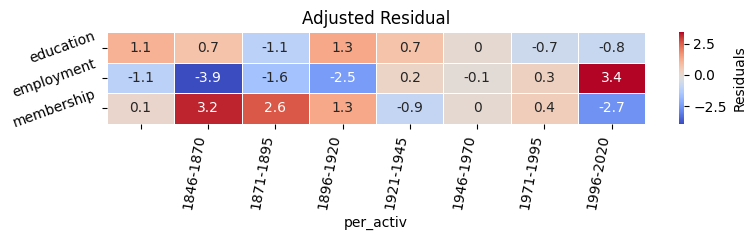

In [43]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 2.5))

## Relationships with organisations in relation to periods: analysis per relationship type

### Universities - education

In [44]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='education']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['per_activ'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

In [45]:
### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
## We take only the 20 organisations with more relationships
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct


Number of persons per organisation and period: 674


per_activ,,1846-1870,1871-1895,1896-1920,1921-1945,1946-1970,1971-1995,1996-2020,sum
Harvard University,0,0,0,2,6,14,22,5,49
University of Chicago,0,0,0,1,8,12,12,4,37
University of Warsaw,1,0,0,0,1,5,18,10,35
École Normale Supérieure,1,0,2,9,3,5,7,3,30
"Faculty of Philosophy and Sociology, University of Warsaw",3,0,0,0,2,5,11,8,29
Columbia University,1,0,0,1,9,10,7,1,29
London School of Economics and Political Science,0,0,0,0,3,8,13,1,25
Humboldt-Universität zu Berlin,2,1,1,6,4,1,2,5,22
University of Paris,0,2,2,2,1,4,9,1,21
Heidelberg University,0,0,3,4,6,5,3,0,21


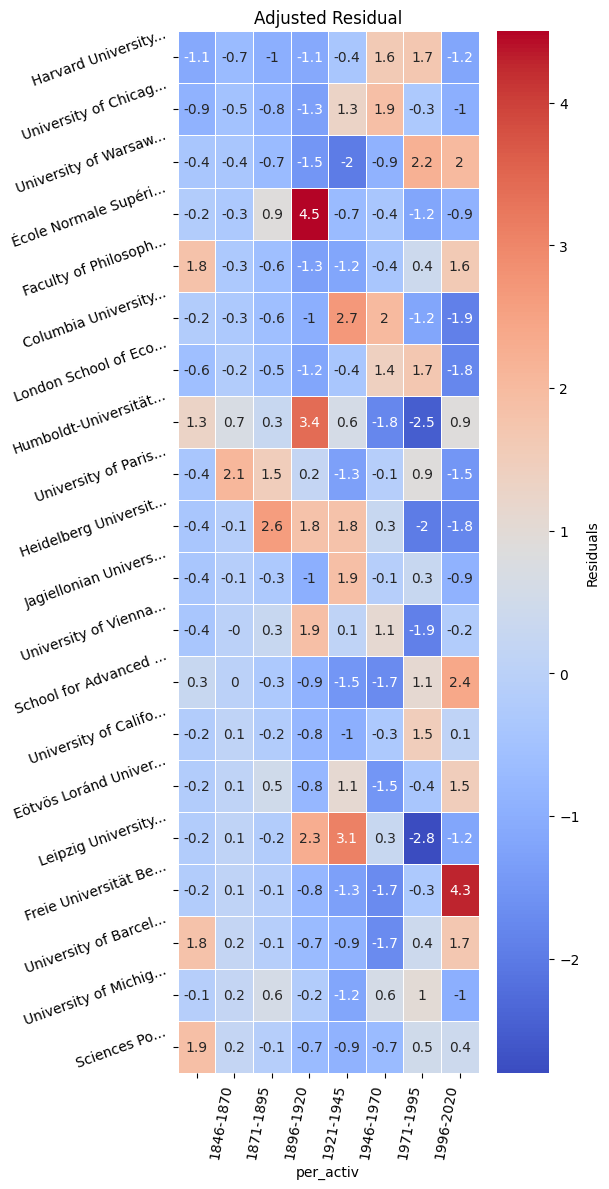

In [46]:
### Specific periods with the residuals heatmap on the corrtable
cct.index=[e[:20]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,12))

### Employers

In [47]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='employment']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['per_activ'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct

Number of persons per organisation and period: 844


per_activ,,1846-1870,1871-1895,1896-1920,1921-1945,1946-1970,1971-1995,1996-2020,sum
University of Warsaw,1,0,0,0,2,11,23,12,49
Harvard University,0,0,0,2,5,17,17,5,46
University of Chicago,0,0,0,5,11,17,11,2,46
Columbia University,0,0,0,2,6,10,10,4,32
"University of California, Berkeley",0,0,0,0,2,9,12,4,27
London School of Economics and Political Science,0,0,0,2,4,7,8,6,27
Humboldt-Universität zu Berlin,1,0,1,4,6,3,5,6,26
Yale University,0,0,1,0,4,7,4,4,20
University of Michigan,0,0,0,1,1,7,11,0,20
University of Vienna,0,1,1,4,3,3,3,5,20


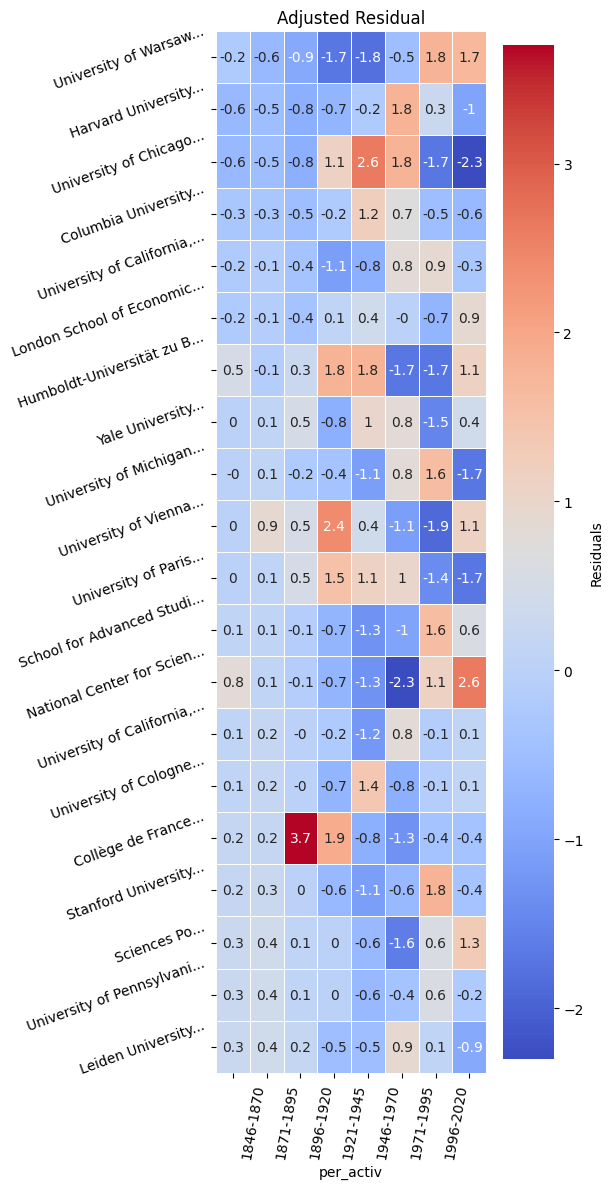

In [48]:
cct.index=[e[:25]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,12))

### Memberships

In [49]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='membership']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['per_activ'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct

Number of persons per organisation and period: 753


per_activ,,1846-1870,1871-1895,1896-1920,1921-1945,1946-1970,1971-1995,1996-2020,sum
American Academy of Arts and Sciences,0,3,1,8,19,71,72,14,188
Academia Europaea,0,0,0,0,0,9,47,24,80
National Academy of Sciences,0,1,0,1,5,24,22,4,57
American Philosophical Society,0,0,1,3,11,24,11,1,51
Polish Sociological Association,2,0,0,0,1,15,17,6,41
British Academy,0,0,0,0,3,13,18,2,36
Accademia Nazionale dei Lincei,0,4,5,3,8,3,7,2,32
Romanian Academy,0,1,2,5,11,9,3,0,31
Sozialistischer Deutscher Studentenbund,0,0,0,0,0,0,28,0,28
Hungarian Academy of Sciences,0,0,1,2,5,5,13,2,28


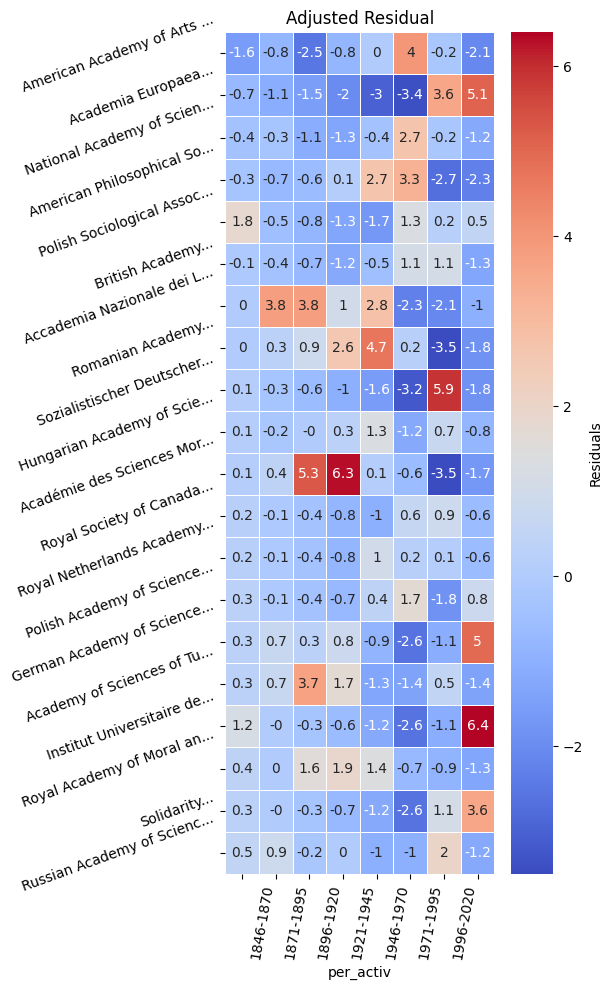

In [50]:
cct.index=[e[:25]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,10))

## Add years to approximate possible relations


In this exercice we artificially build relationships between persons without providing a measure of their real match to reality. In a heuristic perspective, the aim is just to have a consistent network in view of applying some analysis techniques.


We model artificial or imputed encounters based on the idea that persons present in the same institutions in the same period virtually know each other. But this is not alway the case although it allows to build person networks around organisations.

In [51]:
### fonction that codes the year of begin of an 'encounter'
def code_year_begin(type_relation, year):
    if type_relation=='education':
        begin=int(year)+20
    elif type_relation=='employment':
        begin=int(year)+28
    elif type_relation=='membership':
        begin=int(year)+40
    else :
        begin = 0

    return begin    

In [52]:
### function that codes the year of end of the virtual "encounter"
def code_year_end(type_relation, year):
    if type_relation=='education':
        end=int(year)+28
    elif type_relation=='employment':
        end=int(year)+65
    elif type_relation=='membership':
        end=int(year)+65
    else :
        end = 0
        
    return end

In [53]:
### Apply the functions 
df_rel['year_begin'] = df_rel.apply(lambda x : code_year_begin(x['relationship'], x['birthYear']), axis=1)
df_rel['year_end'] = df_rel.apply(lambda x : code_year_end(x['relationship'], x['birthYear']), axis=1)

In [54]:
### Inspect the coding
df_rel[df_rel.relationship=='membership'].iloc[10:15]

,person_uri,organisation_uri,organisation_label,relationship,labelPer,gender,birthYear,country,per_activ,year_begin,year_end
31,http://www.wikidata.org/entity/Q101842,http://www.wikidata.org/entity/Q2043519,PEN Germany,membership,Horst Herrmann,male,1940,Austria Hungary,1971-1995,1980,2005
32,http://www.wikidata.org/entity/Q102086,http://www.wikidata.org/entity/Q1226540,German News Information Services GmbH,membership,Karl Heinz Roth,male,1942,Germany,1971-1995,1982,2007
34,http://www.wikidata.org/entity/Q102086,http://www.wikidata.org/entity/Q2349243,Stiftung für Sozialgeschichte des 20. Jahrhund...,membership,Karl Heinz Roth,male,1942,Germany,1971-1995,1982,2007
36,http://www.wikidata.org/entity/Q102086,http://www.wikidata.org/entity/Q558439,Sozialistischer Deutscher Studentenbund,membership,Karl Heinz Roth,male,1942,Germany,1971-1995,1982,2007
37,http://www.wikidata.org/entity/Q102106,http://www.wikidata.org/entity/Q299015,Austrian Academy of Sciences,membership,Stephan Moebius,male,1973,Germany,1996-2020,2013,2038


## Create pairs of persons: education

Create relations of persons through relations to organisations

In [55]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='education'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'per_activ']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

1685


In [56]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_edu = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_edu))

16715


In [57]:
### Inspect
merged_edu.head(2)

,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
0,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q851164,Corvinus University of Budapest,1951,1959,1971-1995,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,1951,1959,1971-1995
1,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q851164,Corvinus University of Budapest,1951,1959,1971-1995,http://www.wikidata.org/entity/Q1177958,Ferenc Miszlivetz,1974,1982,1996-2020


In [58]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_edu = merged_edu[merged_edu['person_uri_x'] < (merged_edu['person_uri_y'])]
print(len(merged_edu), '-', len(merged_edu)*2)

7515 - 15030


In [59]:
### Restrict time overlap (allow only 7 years overlap) — could be extended to have a larger result

# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_edu = merged_edu[(merged_edu['year_begin_y'] < merged_edu['year_end_x']) & (merged_edu['year_begin_x'] < merged_edu['year_end_y'])]
print(len(merged_edu))

## We observe that linked people are not necessarily in the same activity period
merged_edu.head(3)


1384


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
4,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q851164,Corvinus University of Budapest,1951,1959,1971-1995,http://www.wikidata.org/entity/Q538477,Iván Szelényi,1958,1966,1971-1995
58,http://www.wikidata.org/entity/Q101440467,Audrey Célestine,http://www.wikidata.org/entity/Q859363,Sciences Po,2000,2008,,http://www.wikidata.org/entity/Q91444798,Markéta Sedláčková,1996,2004,
66,http://www.wikidata.org/entity/Q101842,Horst Herrmann,http://www.wikidata.org/entity/Q153978,University of Tübingen,1960,1968,1971-1995,http://www.wikidata.org/entity/Q112671,Peter Flora,1964,1972,1971-1995


In [60]:
### Number of educational relations per university 
gbe_edu = duckdb.query("""
    
    SELECT organisation_label, COUNT(*) as number
    FROM merged_edu
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_edu.iloc[:10]

,organisation_label,number
0,Harvard University,215
1,University of Warsaw,133
2,University of Chicago,122
3,"Faculty of Philosophy and Sociology, Universit...",94
4,Columbia University,86
5,London School of Economics and Political Science,60
6,École Normale Supérieure,43
7,School for Advanced Studies in the Social Scie...,41
8,Heidelberg University,36
9,Jagiellonian University,32


### Aggregate relationships during studies

#### Example of connected persons

Displayed with **Allegrograph Gruff**

<img src="images/alg_gruff_example_chinese_connected_education.png" alt="drawing" width="700"/>

In [61]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_edu = merged_edu.groupby(by=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'per_activ_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_edu['number'] = gr_edu.organisation_label.apply(lambda x : len(x.split('|')))

print('Length Edu Network:', len(gr_edu))


Length Edu Network: 1358


In [62]:
gr_edu=gr_edu.reset_index()
gr_edu.sort_values(by='number', ascending=False).head()

,person_uri_x,person_uri_y,per_activ_x,year_begin_x,year_end_x,year_begin_y,year_end_y,per_activ_y,organisation_label,organisation_uri,number
451,http://www.wikidata.org/entity/Q158060,http://www.wikidata.org/entity/Q9387,1896-1920,1888,1896,1884,1892,1896-1920,Heidelberg University|Humboldt-Universität zu ...,http://www.wikidata.org/entity/Q151510|http://...,2
1349,http://www.wikidata.org/entity/Q919081,http://www.wikidata.org/entity/Q9387,1896-1920,1884,1892,1884,1892,1896-1920,Heidelberg University|University of Strasbourg,http://www.wikidata.org/entity/Q151510|http://...,2
613,http://www.wikidata.org/entity/Q193257,http://www.wikidata.org/entity/Q333686,1946-1970,1944,1952,1945,1953,1946-1970,Lycée Louis-le-Grand|University of Paris,http://www.wikidata.org/entity/Q1059546|http:/...,2
1204,http://www.wikidata.org/entity/Q591030,http://www.wikidata.org/entity/Q943311,1971-1995,1964,1972,1961,1969,1971-1995,"Stanford University|University of California, ...",http://www.wikidata.org/entity/Q41506|http://w...,2
416,http://www.wikidata.org/entity/Q14948743,http://www.wikidata.org/entity/Q310956,1971-1995,1952,1960,1946,1954,1971-1995,Harvard University|Antioch College,http://www.wikidata.org/entity/Q13371|http://w...,2


In [63]:
### change columns names
gr_edu.columns=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'per_activ_y', 'orgs_labels', 'orgs_uris', 'orgs_number']
### change columns positions
gr_edu = gr_edu[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'per_activ_x',  'per_activ_y']]
gr_edu.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
451,http://www.wikidata.org/entity/Q158060,http://www.wikidata.org/entity/Q9387,Heidelberg University|Humboldt-Universität zu ...,2,http://www.wikidata.org/entity/Q151510|http://...,1896-1920,1896-1920
1349,http://www.wikidata.org/entity/Q919081,http://www.wikidata.org/entity/Q9387,Heidelberg University|University of Strasbourg,2,http://www.wikidata.org/entity/Q151510|http://...,1896-1920,1896-1920


In [64]:
### The overwhelming majority of the population has only one study relationship
print('More then 2 relations:', len(gr_edu[gr_edu.orgs_number>2]), '\n2 relations:', len(gr_edu[gr_edu.orgs_number==2]),
      '\none relation:', len(gr_edu[gr_edu.orgs_number==1]))

More then 2 relations: 0 
2 relations: 26 
one relation: 1332


In [65]:
### Find persons in different periods

# Related persons can belong to different periods

## We observe that there is significant overlap: 
## These people and pairs represent BRIDGES between periods !

print(len(gr_edu[gr_edu.per_activ_x != gr_edu.per_activ_y]))
gr_edu[gr_edu.per_activ_x != gr_edu.per_activ_y].sort_values(by='orgs_number', ascending=False).iloc[:5]

211


,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
224,http://www.wikidata.org/entity/Q1177958,http://www.wikidata.org/entity/Q2711710,"Harvard University|University of California, B...",2,http://www.wikidata.org/entity/Q13371|http://w...,1996-2020,1971-1995
212,http://www.wikidata.org/entity/Q11737860,http://www.wikidata.org/entity/Q7156231,"Faculty of Philosophy and Sociology, Universit...",2,http://www.wikidata.org/entity/Q9379430|http:/...,1971-1995,1996-2020
167,http://www.wikidata.org/entity/Q11713930,http://www.wikidata.org/entity/Q9153439,University of Warsaw|Faculty of Philosophy and...,2,http://www.wikidata.org/entity/Q144488|http://...,1971-1995,1996-2020
433,http://www.wikidata.org/entity/Q156268,http://www.wikidata.org/entity/Q333686,Lycée Louis-le-Grand|École Normale Supérieure,2,http://www.wikidata.org/entity/Q1059546|http:/...,1971-1995,1946-1970
1291,http://www.wikidata.org/entity/Q6834209,http://www.wikidata.org/entity/Q7150264,Harvard University|Swarthmore College,2,http://www.wikidata.org/entity/Q13371|http://w...,1971-1995,1996-2020


## Create pairs of persons: employment


Create relations of persons through relations to organisations

In [66]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='employment'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'per_activ']].copy(deep=True)
### Order by person_uri
# df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

2011


In [67]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_empl = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_empl))


19223


In [68]:
merged_empl.head(2)

,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
0,http://www.wikidata.org/entity/Q1000087,Horst Baier,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,1961,1998,1971-1995,http://www.wikidata.org/entity/Q1000087,Horst Baier,1961,1998,1971-1995
1,http://www.wikidata.org/entity/Q1000087,Horst Baier,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,1961,1998,1971-1995,http://www.wikidata.org/entity/Q1714580,Jutta Allmendinger,1984,2021,1996-2020


In [69]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_empl = merged_empl[merged_empl['person_uri_x'] < (merged_empl['person_uri_y'])]
print(len(merged_empl), '-', len(merged_empl)*2)

8606 - 17212


In [70]:
### Restrict time overlap : from 28 to 65
# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_empl = merged_empl[(merged_empl['year_begin_y'] < merged_empl['year_end_x']) & (merged_empl['year_begin_x'] < merged_empl['year_end_y'])]
print(len(merged_empl))

## We observe that linked people are not necessarily in the same activity period
merged_empl.head(3)


6084


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
1,http://www.wikidata.org/entity/Q1000087,Horst Baier,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,1961,1998,1971-1995,http://www.wikidata.org/entity/Q1714580,Jutta Allmendinger,1984,2021,1996-2020
2,http://www.wikidata.org/entity/Q1000087,Horst Baier,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,1961,1998,1971-1995,http://www.wikidata.org/entity/Q152388,Theodor W. Adorno,1931,1968,1946-1970
3,http://www.wikidata.org/entity/Q1000087,Horst Baier,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,1961,1998,1971-1995,http://www.wikidata.org/entity/Q215896,Alfred Schmidt,1959,1996,1971-1995


In [71]:
### Organisations with most frequent co-employments
gbe_empl = duckdb.query("""
    SELECT organisation_label, COUNT(*) as number
    FROM merged_empl
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_empl.iloc[:10]

,organisation_label,number
0,University of Warsaw,937
1,Harvard University,784
2,University of Chicago,716
3,Columbia University,309
4,"University of California, Berkeley",277
5,London School of Economics and Political Science,208
6,University of Michigan,159
7,Humboldt-Universität zu Berlin,142
8,National Center for Scientific Research,130
9,School for Advanced Studies in the Social Scie...,122


### Create network of persons relationships during emloyment

In [72]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_empl = merged_empl.groupby(by=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'per_activ_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_empl['number'] = gr_empl.organisation_label.apply(lambda x : len(x.split('|')))

print(len(gr_empl))


5867


In [73]:
gr_empl=gr_empl.reset_index()
gr_empl.sort_values(by='number', ascending=False).head(2)

,person_uri_x,person_uri_y,per_activ_x,year_begin_x,year_end_x,year_begin_y,year_end_y,per_activ_y,organisation_label,organisation_uri,number
3125,http://www.wikidata.org/entity/Q231349,http://www.wikidata.org/entity/Q5233147,1946-1970,1949,1986,1952,1989,1946-1970,University of Chicago|Northwestern University|...,http://www.wikidata.org/entity/Q131252|http://...,3
2048,http://www.wikidata.org/entity/Q160640,http://www.wikidata.org/entity/Q3093824,1946-1970,1933,1970,1919,1956,1921-1945,University of Paris|École pratique des hautes ...,http://www.wikidata.org/entity/Q209842|http://...,3


In [74]:
### change columns names
gr_empl.columns=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'per_activ_y', 'orgs_labels', 'orgs_uris', 'orgs_number']
### change columns positions
gr_empl = gr_empl[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'per_activ_x', 'per_activ_y']]
gr_empl.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
3125,http://www.wikidata.org/entity/Q231349,http://www.wikidata.org/entity/Q5233147,University of Chicago|Northwestern University|...,3,http://www.wikidata.org/entity/Q131252|http://...,1946-1970,1946-1970
2048,http://www.wikidata.org/entity/Q160640,http://www.wikidata.org/entity/Q3093824,University of Paris|École pratique des hautes ...,3,http://www.wikidata.org/entity/Q209842|http://...,1946-1970,1921-1945


In [75]:
### The overwhelming majority of the population has only one occupation relationship
print('More then 2 relations:', len(gr_empl[gr_empl.orgs_number>2]), 
      '\n2 relations:', len(gr_empl[gr_empl.orgs_number==2]),
      '\n1 relations:', len(gr_empl[gr_empl.orgs_number==1]))
print(f'Maximum number of relationships in employments: {gr_empl.orgs_number.max()}')

More then 2 relations: 8 
2 relations: 201 
1 relations: 5658
Maximum number of relationships in employments: 3


## Create pairs of persons: membership

Create relations of persons through relations to organisations

In [76]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='membership'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'per_activ']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

2043


In [77]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_memb = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_memb))


63639


In [78]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_memb = merged_memb[merged_memb['person_uri_x'] < (merged_memb['person_uri_y'])]
print(len(merged_memb), '-', len(merged_memb)*2)

30798 - 61596


In [79]:
### Restrict time overlap (allow only 7 years overlap) — could be extended to have a larger result

# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_memb = merged_memb[(merged_memb['year_begin_y'] < merged_memb['year_end_x']) & (merged_memb['year_begin_x'] < merged_memb['year_end_y'])]
print(len(merged_memb))

## We observe that linked people are not necessarily in the same activity period
merged_memb.head(3)


18155


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
3,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,1971,1996,1971-1995,http://www.wikidata.org/entity/Q1096729,István Imreh,1959,1984,1946-1970
4,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,1971,1996,1971-1995,http://www.wikidata.org/entity/Q1105097,Viktor Karády,1976,2001,1971-1995
5,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,1971,1996,1971-1995,http://www.wikidata.org/entity/Q1106778,István Kemény,1965,1990,1946-1970


In [80]:
### count membership relations by organisation
gbe_memb=duckdb.query("""
    SELECT organisation_label, COUNT(*) as number
    FROM merged_memb
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_memb.iloc[:10]

,organisation_label,number
0,American Academy of Arts and Sciences,9867
1,Academia Europaea,2497
2,National Academy of Sciences,943
3,American Philosophical Society,769
4,Polish Sociological Association,511
5,British Academy,384
6,Sozialistischer Deutscher Studentenbund,378
7,Romanian Academy,194
8,Hungarian Academy of Sciences,188
9,Royal Society of Canada,164


### Create network of persons relationships during membership

In [81]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_memb = merged_memb.groupby(by=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'per_activ_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_memb['number'] = gr_memb.organisation_label.apply(lambda x : len(x.split('|')))
gr_memb=gr_memb.reset_index()
print(len(gr_memb))


16262


In [82]:
### Inspect grouped membership relationships
gr_memb.sort_values(by='number', ascending=False).head()

,person_uri_x,person_uri_y,per_activ_x,year_begin_x,year_end_x,year_begin_y,year_end_y,per_activ_y,organisation_label,organisation_uri,number
11008,http://www.wikidata.org/entity/Q312843,http://www.wikidata.org/entity/Q76959,1946-1970,1950,1975,1969,1994,1971-1995,National Academy of Sciences|American Academy ...,http://www.wikidata.org/entity/Q270794|http://...,5
14431,http://www.wikidata.org/entity/Q539414,http://www.wikidata.org/entity/Q81244,1946-1970,1951,1976,1942,1967,1946-1970,British Academy|Royal Society|National Academy...,http://www.wikidata.org/entity/Q723551|http://...,4
15704,http://www.wikidata.org/entity/Q713936,http://www.wikidata.org/entity/Q76959,1971-1995,1970,1995,1969,1994,1971-1995,Russian Academy of Sciences|American Philosoph...,http://www.wikidata.org/entity/Q83172|http://w...,4
2979,http://www.wikidata.org/entity/Q1352604,http://www.wikidata.org/entity/Q312843,1971-1995,1968,1993,1950,1975,1946-1970,American Academy of Arts and Sciences|American...,http://www.wikidata.org/entity/Q463303|http://...,4
2339,http://www.wikidata.org/entity/Q128126,http://www.wikidata.org/entity/Q83907,1946-1970,1948,1973,1955,1980,1946-1970,National Academy of Sciences|American Academy ...,http://www.wikidata.org/entity/Q270794|http://...,4


In [83]:
### change columns names
gr_memb.columns=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'per_activ_y', 'orgs_labels', 'orgs_uris', 'orgs_number']

In [84]:
### change columns positions
gr_memb = gr_memb[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'per_activ_x', 'per_activ_y']]
gr_memb.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
11008,http://www.wikidata.org/entity/Q312843,http://www.wikidata.org/entity/Q76959,National Academy of Sciences|American Academy ...,5,http://www.wikidata.org/entity/Q270794|http://...,1946-1970,1971-1995
14431,http://www.wikidata.org/entity/Q539414,http://www.wikidata.org/entity/Q81244,British Academy|Royal Society|National Academy...,4,http://www.wikidata.org/entity/Q723551|http://...,1946-1970,1946-1970


In [85]:
print('More then 2 relations:', len(gr_memb[gr_memb.orgs_number>2]), 
      '\n2 relations:', len(gr_memb[gr_memb.orgs_number==2]),
      '\none relation:', len(gr_memb[gr_memb.orgs_number==1]))
print(f'Maximum number of relations in memberships: {gr_memb.orgs_number.max()}')

More then 2 relations: 255 
2 relations: 1372 
one relation: 14635
Maximum number of relations in memberships: 5


In [86]:
print('More then 4 relations:', len(gr_memb[gr_memb.orgs_number>4]), 
      '\n4 relations:', len(gr_memb[gr_memb.orgs_number==4]),
      '\n3 relations:', len(gr_memb[gr_memb.orgs_number==3]))

More then 4 relations: 1 
4 relations: 9 
3 relations: 245


In [87]:
print('More then 10 relations:', len(gr_memb[gr_memb.orgs_number>10]), '\n10 relations:', len(gr_memb[gr_memb.orgs_number==10]))

More then 10 relations: 0 
10 relations: 0


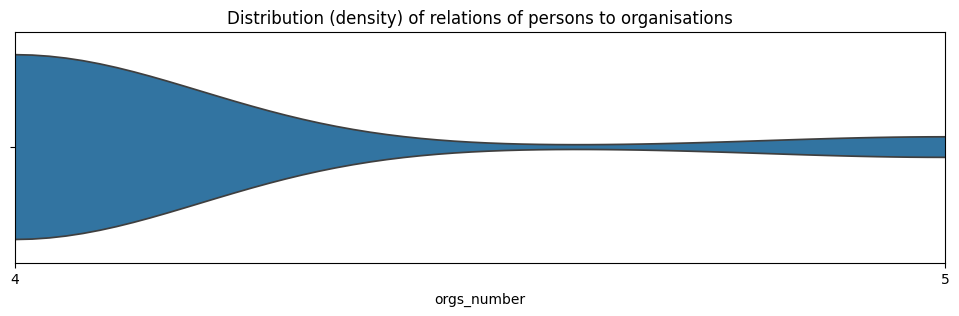

In [89]:
# Plot the distribution of eigenvector density

df=gr_memb[gr_memb.orgs_number>3]

min_val = df.orgs_number.min()
max_val = df.orgs_number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.orgs_number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

## Most frequent organisations as relations

Organisations where memberships' relationship happen are different from those where people are educated and are employed, as we can see if we compare the tables below.

We therefore just join educational institutions and employers

In [90]:
### Study
gbe_edu.head(10)

,organisation_label,number
0,Harvard University,215
1,University of Warsaw,133
2,University of Chicago,122
3,"Faculty of Philosophy and Sociology, Universit...",94
4,Columbia University,86
5,London School of Economics and Political Science,60
6,École Normale Supérieure,43
7,School for Advanced Studies in the Social Scie...,41
8,Heidelberg University,36
9,Jagiellonian University,32


In [91]:
### Employment
gbe_empl.head(10)

,organisation_label,number
0,University of Warsaw,937
1,Harvard University,784
2,University of Chicago,716
3,Columbia University,309
4,"University of California, Berkeley",277
5,London School of Economics and Political Science,208
6,University of Michigan,159
7,Humboldt-Universität zu Berlin,142
8,National Center for Scientific Research,130
9,School for Advanced Studies in the Social Scie...,122


In [92]:
### Join first hundred organisation for education and employment

gb_organ_of_rel=pd.merge(left=gbe_edu, on='organisation_label', right=gbe_empl,
                suffixes=('_rel_edu', '_rel_empl'), how='outer')
gb_organ_of_rel[['number_rel_edu','number_rel_empl']]=gb_organ_of_rel[['number_rel_edu','number_rel_empl']].fillna(0).astype('int')
print(len(gb_organ_of_rel))
gb_organ_of_rel.head()

145


,organisation_label,number_rel_edu,number_rel_empl
0,AGH University of Science and Technology,0,6
1,Adam Mickiewicz University in Poznań,4,15
2,Antioch College,3,0
3,Autonomous University of Barcelona,17,50
4,Bielefeld University,0,28


In [93]:
### Inspect most frequent organisations, order by study
gb_organ_of_rel.sort_values(by='number_rel_edu', ascending=False).iloc[:10]

,organisation_label,number_rel_edu,number_rel_empl
34,Harvard University,215,784
132,University of Warsaw,133,937
93,University of Chicago,122,716
26,"Faculty of Philosophy and Sociology, Universit...",94,0
14,Columbia University,86,309
51,London School of Economics and Political Science,60,208
143,École Normale Supérieure,43,0
70,School for Advanced Studies in the Social Scie...,41,122
35,Heidelberg University,36,24
42,Jagiellonian University,32,33


In [94]:
### Inspect most frequent organisations, order by employer
# Note the difference, e.g. the MSU Faculty of Physcs has no employee ... 
# There should be a bias in the data (not yet verified)
# See also CERN and Bell Labs
gb_organ_of_rel.sort_values(by='number_rel_empl', ascending=False).iloc[:30]


,organisation_label,number_rel_edu,number_rel_empl
132,University of Warsaw,133,937
34,Harvard University,215,784
93,University of Chicago,122,716
14,Columbia University,86,309
89,"University of California, Berkeley",31,277
51,London School of Economics and Political Science,60,208
115,University of Michigan,14,159
36,Humboldt-Universität zu Berlin,31,142
60,National Center for Scientific Research,0,130
70,School for Advanced Studies in the Social Scie...,41,122


In [95]:
### Membership
# These are totally different institution with regard to the former ones
gbe_memb.head(10)

,organisation_label,number
0,American Academy of Arts and Sciences,9867
1,Academia Europaea,2497
2,National Academy of Sciences,943
3,American Philosophical Society,769
4,Polish Sociological Association,511
5,British Academy,384
6,Sozialistischer Deutscher Studentenbund,378
7,Romanian Academy,194
8,Hungarian Academy of Sciences,188
9,Royal Society of Canada,164


## Merge the three networks: where do the encounters happen?

We merge the three tables of relations (education, employment, membership) and observe where encounters happen.

In [96]:
### Join educational and employment persons' pairs
# All relationships are kept, left and right join -> outer
network=pd.merge(gr_edu, gr_empl, on=['person_uri_x', 'person_uri_y', 'per_activ_x', 'per_activ_y'],
                 how='outer', suffixes=('_edu', '_empl'), indicator=True)
network.rename(columns={'_merge': 'merge_1'}, inplace=True)

In [97]:
print('Number of edu+empl pairs:',len(network))
network.sort_values(by='orgs_number_edu', ascending=False).head(2)

Number of edu+empl pairs: 7005


,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,orgs_uris_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_uris_empl,merge_1
2196,http://www.wikidata.org/entity/Q158060,http://www.wikidata.org/entity/Q9387,Heidelberg University|Humboldt-Universität zu ...,2.0,http://www.wikidata.org/entity/Q151510|http://...,1896-1920,1896-1920,NaN,NaN,NaN,left_only
6973,http://www.wikidata.org/entity/Q919081,http://www.wikidata.org/entity/Q9387,Heidelberg University|University of Strasbourg,2.0,http://www.wikidata.org/entity/Q151510|http://...,1896-1920,1896-1920,NaN,NaN,NaN,left_only


In [98]:
### Join to network the membership persons' pairs
# All relationships are kept, left and right join -> outer
network=pd.merge(network, gr_memb, on=['person_uri_x', 'person_uri_y', 'per_activ_x', 'per_activ_y' ],
                 how='outer', suffixes=('', '_memb'), indicator=True)
network.rename(columns={'orgs_labels': 'orgs_labels_memb','orgs_number': 'orgs_number_memb','organisation_uri': 'orgs_uris_memb'}, inplace=True)

In [99]:
network['orgs_number_edu'].fillna(0, inplace=True)
network['orgs_number_empl'].fillna(0, inplace=True)
network['orgs_number_memb'].fillna(0, inplace=True)
network['orgs_number_memb']=network['orgs_number_memb'].astype(int)
network['orgs_number_edu']=network['orgs_number_edu'].astype(int)
network['orgs_number_empl']=network['orgs_number_empl'].astype(int)
network=network[['person_uri_x', 'person_uri_y', 'orgs_labels_edu', 'orgs_number_edu', 'per_activ_x', 'per_activ_y', 'orgs_labels_empl', 'orgs_number_empl', 'orgs_labels_memb', 'orgs_number_memb']]

In [100]:
print('Number of edu+empl+memb pairs:',len(network))
network.iloc[550:555]

Number of edu+empl+memb pairs: 21059


,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb
550,http://www.wikidata.org/entity/Q1065979,http://www.wikidata.org/entity/Q919081,NaN,0,1921-1945,1896-1920,Fisk University,1,NaN,0
551,http://www.wikidata.org/entity/Q1065979,http://www.wikidata.org/entity/Q990849,University of Chicago,1,1921-1945,1921-1945,NaN,0,NaN,0
552,http://www.wikidata.org/entity/Q106694,http://www.wikidata.org/entity/Q1261657,NaN,0,1971-1995,1971-1995,NaN,0,European Academy of Sciences and Arts,1
553,http://www.wikidata.org/entity/Q106694,http://www.wikidata.org/entity/Q156268,NaN,0,1971-1995,1971-1995,NaN,0,European Academy of Sciences and Arts,1
554,http://www.wikidata.org/entity/Q106694,http://www.wikidata.org/entity/Q1614826,NaN,0,1971-1995,1946-1970,NaN,0,European Academy of Sciences and Arts,1


In [101]:
### create field with sum of edu and empl
network['sum_edu_empl']=network['orgs_number_edu']+network['orgs_number_empl']

In [102]:
### create field with sum of all values
network['sum_all_rel']=network['orgs_number_edu']+network['orgs_number_empl']+network['orgs_number_memb']

#### Add persons' labels

In [103]:
network=pd.merge(left=network,right=df_p[['person_uri','labelPer','birthYear']], left_on='person_uri_x', right_on='person_uri')

In [104]:
network.drop(columns=['person_uri'], inplace=True)

In [105]:
network=pd.merge(left=network,right=df_p[['person_uri','labelPer','birthYear']], left_on='person_uri_y', right_on='person_uri', suffixes=('_x1', '_y'))


In [106]:
network.head(2)

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb,sum_edu_empl,sum_all_rel,labelPer_x1,birthYear_x1,person_uri,labelPer_y,birthYear_y
0,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q152388,NaN,0,1971-1995,1946-1970,Goethe University Frankfurt,1,NaN,0,1,1,Horst Baier,1933,http://www.wikidata.org/entity/Q152388,Theodor W. Adorno,1903
1,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q1714580,NaN,0,1971-1995,1996-2020,Goethe University Frankfurt,1,NaN,0,1,1,Horst Baier,1933,http://www.wikidata.org/entity/Q1714580,Jutta Allmendinger,1956


In [107]:
network.rename(columns={'labelPer_x1': 'labelPer_x','birthYear_x1': 'birthYear_x'}, inplace=True)

In [108]:
network.drop(columns=['person_uri'], inplace=True)

In [109]:
network.head(2)

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb,sum_edu_empl,sum_all_rel,labelPer_x,birthYear_x,labelPer_y,birthYear_y
0,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q152388,NaN,0,1971-1995,1946-1970,Goethe University Frankfurt,1,NaN,0,1,1,Horst Baier,1933,Theodor W. Adorno,1903
1,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q1714580,NaN,0,1971-1995,1996-2020,Goethe University Frankfurt,1,NaN,0,1,1,Horst Baier,1933,Jutta Allmendinger,1956


In [110]:
### Change columns order
network=network[['labelPer_x',
  'labelPer_y',
  'birthYear_x','birthYear_y',
'per_activ_x', 'per_activ_y',
 'sum_edu_empl', ### study and employment relationshipa
 'sum_all_rel', ### all the relationships
 'orgs_number_edu',  'orgs_labels_edu', 
 'orgs_number_empl', 'orgs_labels_empl',
 'orgs_number_memb', 'orgs_labels_memb',
 'person_uri_x', 'person_uri_y'
   ]]

In [111]:
### SQL Queries


# order by max sum of edu and empl relations
query_1="""
    SELECT *
    FROM network
    ORDER BY sum_edu_empl DESC
    LIMIT 5
"""


# order by max sum of all relations
query_2="""
    SELECT * 
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
    ORDER BY sum_all_rel DESC
    --OFFSET 500
    LIMIT 10
"""

# order by max sum of all relations
query_2_count="""
    SELECT COUNT(*) as number  -- 3922
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
"""

# order by max  edu and empl relations
query_3="""
    SELECT *
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
    ORDER BY orgs_number_empl DESC, orgs_number_edu DESC
    --OFFSET 500
    LIMIT 10
"""

In [112]:
duckdb.query(query_2).to_df()

,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Ernst Troeltsch,Max Weber,1865,1864,1896-1920,1896-1920,3,5,2,Humboldt-Universität zu Berlin|University of G...,1,Heidelberg University,2,Bavarian Academy of Sciences and Humanities|He...,http://www.wikidata.org/entity/Q60285,http://www.wikidata.org/entity/Q9387
1,Ernst Troeltsch,Alfred Weber,1865,1868,1896-1920,1896-1920,3,5,1,Humboldt-Universität zu Berlin,2,Heidelberg University|Humboldt-Universität zu ...,2,Bavarian Academy of Sciences and Humanities|He...,http://www.wikidata.org/entity/Q60285,http://www.wikidata.org/entity/Q76514
2,Clyde Kluckhohn,George C. Homans,1905,1910,1946-1970,1946-1970,2,5,1,Harvard University,1,Harvard University,3,American Philosophical Society|National Academ...,http://www.wikidata.org/entity/Q1103678,http://www.wikidata.org/entity/Q163171
3,Raymond Aron,Jean Stoetzel,1905,1910,1946-1970,1946-1970,2,4,1,École Normale Supérieure,1,University of Paris,2,Académie des Sciences Morales et Politiques|Am...,http://www.wikidata.org/entity/Q160640,http://www.wikidata.org/entity/Q3174684
4,Robert Neelly Bellah,Neil Smelser,1927,1930,1971-1995,1971-1995,2,4,1,Harvard University,1,"University of California, Berkeley",2,American Academy of Arts and Sciences|American...,http://www.wikidata.org/entity/Q1353651,http://www.wikidata.org/entity/Q713936
5,George C. Homans,David Riesman,1910,1909,1946-1970,1946-1970,2,4,1,Harvard College,1,Harvard University,2,American Academy of Arts and Sciences|American...,http://www.wikidata.org/entity/Q163171,http://www.wikidata.org/entity/Q504319
6,Heinz Fassmann,Wolfgang Lutz,1955,1956,1996-2020,1996-2020,2,4,1,University of Vienna,1,University of Vienna,2,Academia Europaea|Austrian Academy of Sciences,http://www.wikidata.org/entity/Q1600191,http://www.wikidata.org/entity/Q2590485
7,Pierre Bourdieu,Alain Touraine,1930,1925,1971-1995,1946-1970,3,4,2,Lycée Louis-le-Grand|École Normale Supérieure,1,School for Advanced Studies in the Social Scie...,1,American Academy of Arts and Sciences,http://www.wikidata.org/entity/Q156268,http://www.wikidata.org/entity/Q333686
8,Clyde Kluckhohn,Karl Deutsch,1905,1912,1946-1970,1946-1970,2,4,1,Harvard University,1,Harvard University,2,National Academy of Sciences|American Academy ...,http://www.wikidata.org/entity/Q1103678,http://www.wikidata.org/entity/Q77454
9,George Murdock,Harold Lasswell,1897,1902,1921-1945,1946-1970,2,4,1,Yale University,1,Yale University,2,National Academy of Sciences|American Academy ...,http://www.wikidata.org/entity/Q1361073,http://www.wikidata.org/entity/Q314462


In [113]:
print('Tot:', len(network), 'Edu:', len
      (gr_edu), ', Empl:', len(gr_empl), ', Memb:', len(gr_memb))

Tot: 21059 Edu: 1358 , Empl: 5867 , Memb: 16262


### Store the network on the disk

DO NOT COMMIT THIS FILE IF NOT ADDED *.pkl  TO .gitignore

In [114]:
### BEWARE: add all pickle files to the .gitignore file with this entry . *.pkl

### DO NOT COMMIT THIS FILE IF NOT ADDED *.pkl  TO .gitignore

file_address='da_data/da6-networks.pkl'
network.to_pickle(file_address)

## Correlations

We could wonder if the fact of studying together, or working together would lead to be member of the same organisations.

Given the large amount of people having just one or to relation, we only consider people having at least four relationships.

We use here ranking correlation given that we are counting relations

Surprisingly:
* there is some weak positive relation between studying and working together
* but there is a stronger negative correlation between studying or working together and being member of same organisations 


In [115]:
### ONLY EXECUTE if you need to restart the notebook from the stored network

file_address='da_data/da6-networks.pkl'
network=pd.read_pickle(file_address)
print(len(network))
network.iloc[:3]

21059


,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Horst Baier,Theodor W. Adorno,1933,1903,1971-1995,1946-1970,1,1,0,NaN,1,Goethe University Frankfurt,0,NaN,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q152388
1,Horst Baier,Jutta Allmendinger,1933,1956,1971-1995,1996-2020,1,1,0,NaN,1,Goethe University Frankfurt,0,NaN,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q1714580
2,Horst Baier,Alfred Schmidt,1933,1931,1971-1995,1971-1995,1,1,0,NaN,1,Goethe University Frankfurt,0,NaN,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q215896


In [116]:
### Inspect cooccurrence of pairs, before analysing correlations

# We observe that we have quite sparse data in the network !

print('Total number of relationships:',len(network))
print('Edu', len(network[(network.orgs_number_edu>0)]))
print('Empl', len(network[(network.orgs_number_empl>0)]))
print('Memb', len(network[(network.orgs_number_memb>0)]))
print('Study and work together',len(network[(network.orgs_number_edu>0) & (network.orgs_number_empl>0)]))
print('Study and membership together', len(network[(network.orgs_number_edu>0) & (network.orgs_number_memb>0) ]))
print('Work and membership together',len(network[ (network.orgs_number_empl>0) & (network.orgs_number_memb>0) ]))
print('All three phases together',len(network[(network.orgs_number_edu>0) & (network.orgs_number_empl>0) & (network.orgs_number_memb>0) ]))

Total number of relationships: 21059
Edu 1358
Empl 5867
Memb 16262
Study and work together 220
Study and membership together 405
Work and membership together 1899
All three phases together 96


In [121]:
### We only consider in the distribution more than three
df=network[network.sum_all_rel>3].copy(deep=True)
print(len(df))
print(df.sum_all_rel.describe())

137
count    137.000000
mean       4.058394
std        0.235348
min        4.000000
25%        4.000000
50%        4.000000
75%        4.000000
max        5.000000
Name: sum_all_rel, dtype: float64


In [122]:
print("Total rows:", len(df))
print("Missing values:", df['sum_all_rel'].isna().sum())
print("Data type:", df['sum_all_rel'].dtype)

Total rows: 137
Missing values: 0
Data type: int64


### Measure the correlations

#### Relationships in studies and in employment

We only can use rank correlation given these are counts. 

Also, most educational relations have count: 1 - so the correlation does not really make sense

In [123]:
predictor_name='orgs_number_edu' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_empl'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis: on ranking because these are counts
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.2962 (p-value: 0.0004)


#### Relationships in studies and in membership

In [124]:

predictor_name='orgs_number_edu' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_memb'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis: on ranking because these are counts
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.4325 (p-value: 0.0000)


#### Relationships in employment and in membership

In [125]:

predictor_name='orgs_number_empl' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_memb'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.6649 (p-value: 0.0000)


### Represent the correlations

In [126]:
df=df[['sum_all_rel', 'orgs_number_edu', 
       'orgs_number_empl', 'orgs_number_memb']].\
              sort_values(by=['orgs_number_memb'])
df.reset_index(inplace=True, drop=True)
df.head()

,sum_all_rel,orgs_number_edu,orgs_number_empl,orgs_number_memb
0,4,0,3,1
1,4,2,1,1
2,4,0,3,1
3,4,2,1,1
4,4,1,2,1


In [127]:
# Smooth with gliding mean

# Ensure data is sorted by index (and value)

df['smoothed_memb'] = df['orgs_number_memb'].rolling(window=100, min_periods=1).mean()
df['smoothed_empl'] = df['orgs_number_empl'].rolling(window=100, min_periods=5).mean()
df['smoothed_edu'] = df['orgs_number_edu'].rolling(window=100, min_periods=1).mean()
df['smoothed_all'] = df['sum_all_rel'].rolling(window=100, min_periods=1).mean()



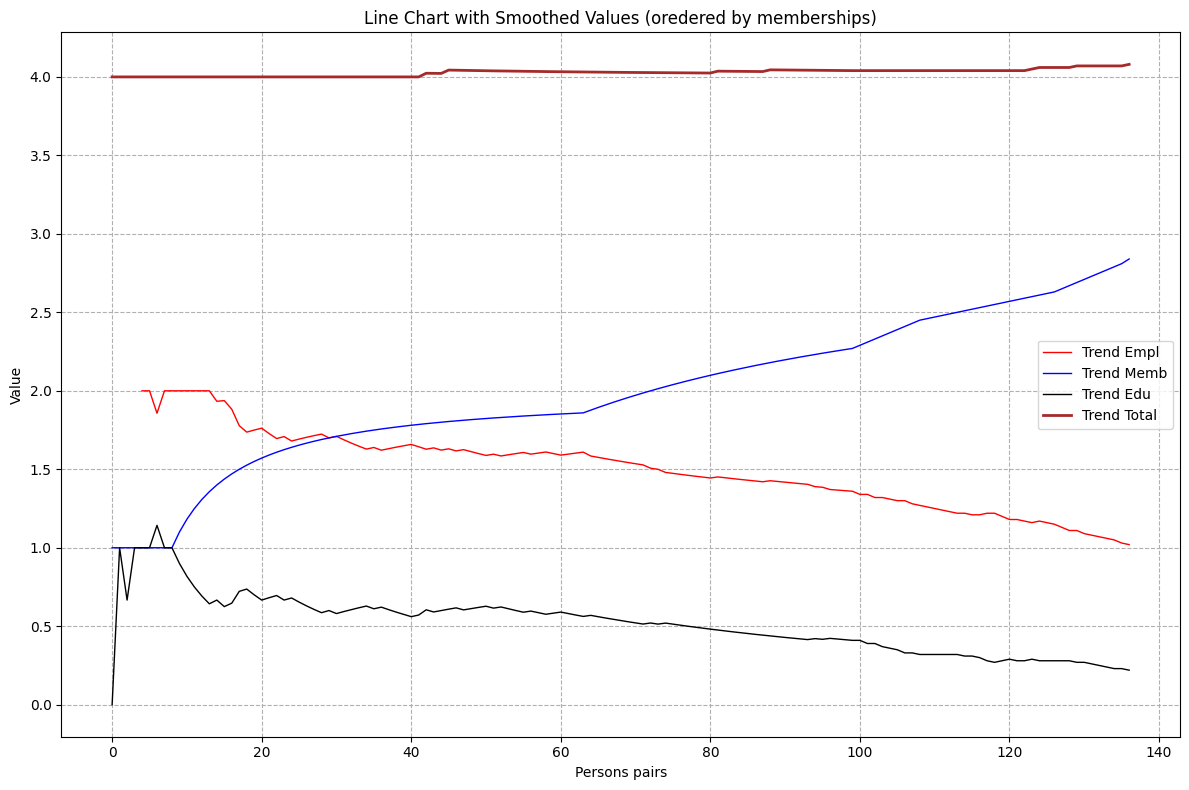

In [128]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(df['smoothed_empl'], linestyle='-', color='red', linewidth=1, label='Trend Empl')
ax.plot(df['smoothed_memb'],  linestyle='-', color='blue', linewidth=1, label='Trend Memb')
ax.plot(df['smoothed_edu'],  linestyle='-', color='black', linewidth=1, label='Trend Edu')
ax.plot(df['smoothed_all'],  linestyle='-', color='brown', linewidth=2, label='Trend Total')

ax.set_xlabel('Persons pairs')
ax.set_ylabel('Value')
ax.set_title('Line Chart with Smoothed Values (oredered by memberships)')
ax.grid(True, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()